# Blue bikes use case: Rents Prediction

Blue bikes is a company located in Boston that wants to predict the number of rents they will got given specific climatic conditions and the hour and day of the week. For that, they have gathered historical data and need to obtain value from it. As a data scientist, I will compare different machine learning methods to provide the requested prediction.

### Step 1: Import necessary libraries

In [1]:
!pip install skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.5 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you

In [98]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import norm
from skimpy import skim
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn import datasets
from sklearn.tree import DecisionTreeRegressor, plot_tree

### Step 2: Load and explore the data

In [99]:
df = pd.read_csv('/data/rentals_weather.csv')

In [100]:
df.head(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation
0,4,1,1,0,Mon,0,2,0,59,16,0.0
1,6,1,1,1,Mon,0,1,0,59,11,0.0
2,6,1,1,2,Mon,0,1,-1,54,21,0.0
3,1,1,1,5,Mon,0,0,-2,54,18,0.0
4,3,1,1,6,Mon,0,0,-2,54,15,0.0
5,3,1,1,7,Mon,0,0,-2,54,11,0.0


In [101]:
df.tail(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation
8597,69,12,31,18,Mon,0,42,37,60,10,0.00
8598,36,12,31,19,Mon,0,39,36,76,13,0.02
8599,25,12,31,20,Mon,0,38,36,86,14,0.04
8600,13,12,31,21,Mon,0,37,36,89,15,0.07
8601,6,12,31,22,Mon,0,38,37,89,14,0.09
8602,7,12,31,23,Mon,0,39,38,89,17,0.19


### Step 3: Define categorical variables

In [102]:
categorical_variables = ['month','day','hour','day_of_week','weekend']
df[categorical_variables] = df[categorical_variables].astype('category')

In [103]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 8603   │ │ int64       │ 5     │ │ month                 │                                │
│ │ Number of columns │ 11     │ │ category    │ 5     │ │ day                   │                                │
│ └───────────────────┴────────┘ │ float64     │ 1     │ │ hour                  │                                │
│                                └─────────────┴───────┘ │ day_of_week           │                                │
│                                                        │ weekend               │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column             ┃ NA   ┃ NA %   ┃ mean       ┃ sd         ┃ p0  ┃ p25   ┃ p50  ┃ p75  ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ rentals            │    0 │      0 │      205.1 │      227.1 │   1 │    32 │  120 │  306 │  1299 │   █▃▁   │  │
│ │ temp               │    0 │      0 │      53.21 │      18.29 │  -2 │    38 │   52 │   69 │    97 │  ▂█▆▇▂  │  │
│ │ temp_wb            │    0 │      0 │      47.84 │      16.91 │  -3 │    34 │   48 │   62 │    81 │  ▂█▇█▅  │  │
│ │ rel_humidity       │    0 │      0 │      67.11 │      18.92 │  16 │    53 │   68 │   84 │   100 │ ▁▃▇█▇▇  │  │
│ │ windspeed          │    0 │      0 │       11.1 │      5.455 │   0 │     7 │   10 │   14 │    48 │   ▄█▂   │  │
│ │ precipitation      │    0 │      0 │    0.00544 │    0.03407 │   0 │     0 │    0 │    0 │  1.12 │    █    │  │
│ └────────────────────┴──────┴────────┴────────────┴────────────┴─────┴───────┴──────┴──────┴───────┴─────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                           ┃ NA        ┃ NA %           ┃ ordered               ┃ unique             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩  │
│ │ month                            │         0 │              0 │ False                 │                 12 │  │
│ │ day                              │         0 │              0 │ False                 │                 31 │  │
│ │ hour                             │         0 │              0 │ False                 │                 24 │  │
│ │ day_of_week                      │         0 │              0 │ False                 │                  7 │  │
│ │ weekend                          │         0 │              0 │ False                 │                  2 │  │
│ └──────────────────────────────────┴───────────┴────────────────┴───────────────────────┴────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

### Step 4: Analyzing with histograms and plots
Lets produce a histogram of rentals data. Select bins based on the summary obtained using 'skim'.
- Histogram of rentals

Text(0, 0.5, 'Number of Data Points')

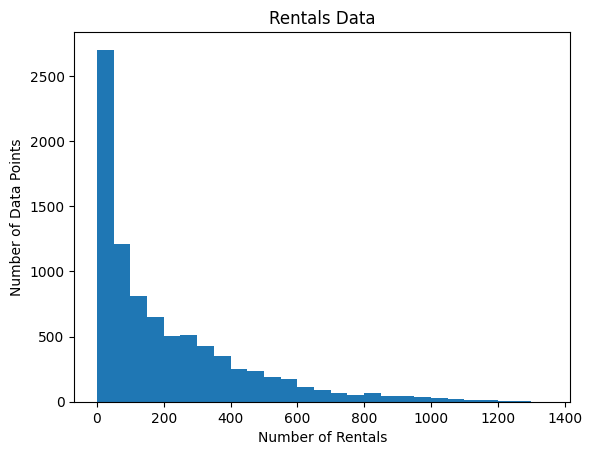

In [104]:
plt.hist(df['rentals'], bins = range(0,1400,50))
plt.title('Rentals Data')
plt.xlabel('Number of Rentals')
plt.ylabel('Number of Data Points')

In [105]:
print("Average no. of Rentals: "+str(np.mean(df['rentals']))+" Standard Dev: "+str(np.std(df['rentals'])))

Average no. of Rentals: 205.08578402882716 Standard Dev: 227.03926517480508


- Histogram of rentals at a temp of 25F.

Text(0, 0.5, 'Number of Data Points')

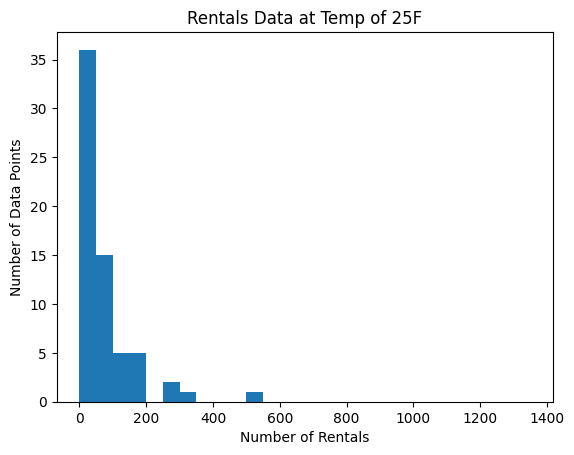

In [106]:
df_cold = df[df['temp']==25]
plt.hist(df_cold['rentals'], bins = range(0,1400,50))
plt.title('Rentals Data at Temp of 25F')
plt.xlabel('Number of Rentals')
plt.ylabel('Number of Data Points')

Standard deviation is now a lot smaller..

In [107]:
print("Average no. of Rentals at 25F: "+str(np.mean(df_cold['rentals']))+" Standard Dev: "+str(np.std(df_cold['rentals'])))

Average no. of Rentals at 25F: 72.55384615384615 Standard Dev: 90.4802623218041


Lets produce scatter plots to see the relations of the columns.
- Rentals vs Hour of day: shows that knowing the hour of rental could potentially reduce variabilit.

Text(0, 0.5, '# Rentals')

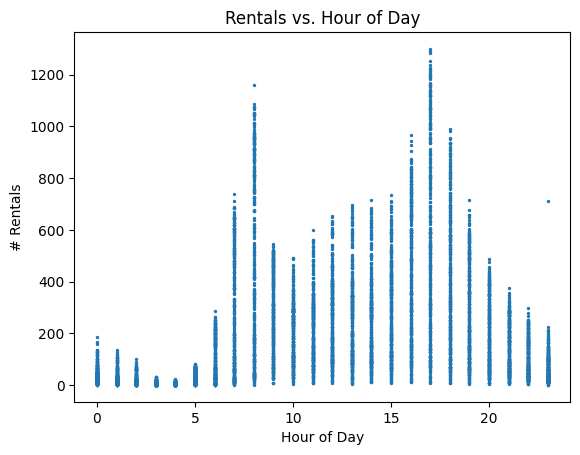

In [108]:
plt.scatter(df['hour'],df['rentals'],s=2)
plt.title('Rentals vs. Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('# Rentals')

- Rentals vs. Temperature: When plotting the mean number of rentals, a definite straight-line like trend could be seen.

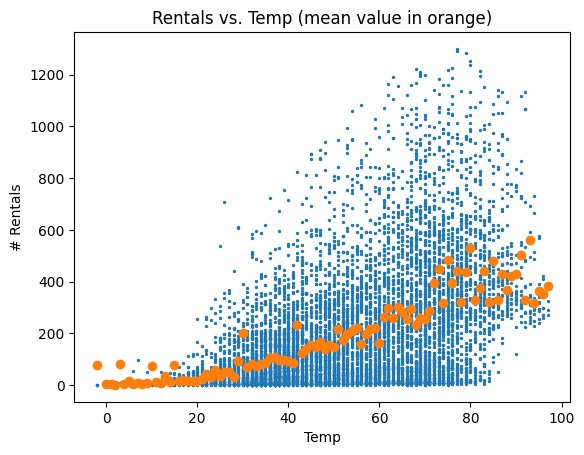

In [109]:
plt.scatter(df['temp'],df['rentals'],s=2)
plt.title('Rentals vs. Temp (mean value in orange)')
plt.xlabel('Temp')
plt.ylabel('# Rentals')
plt.scatter(df['temp'].unique(),df.groupby('temp')['rentals'].mean())

This final scatter plot is the key motivation to try a linear regression. In particular, I will check on correlation and importance of the variable to define the best possible linear regression.

### Step 5: Looking for correlations
High correlation between two independent variables may produce collinearity, which can make our model have unstable coefficients, inflated standard errors and overfitting produced by the noise used. Variables with high correlation may not be included in the regression.

In [110]:
df[['temp',	'temp_wb',	'rel_humidity',	'windspeed',	'precipitation']].corr()

,temp,temp_wb,rel_humidity,windspeed,precipitation
temp,1.000000,0.977801,0.126377,-0.148411,0.018469
temp_wb,0.977801,1.000000,0.319822,-0.188347,0.057638
rel_humidity,0.126377,0.319822,1.000000,-0.218430,0.206801
windspeed,-0.148411,-0.188347,-0.218430,1.000000,0.069177
precipitation,0.018469,0.057638,0.206801,0.069177,1.000000


By the correlation matrix, I can delete temp_wb because is highly correlated with temp. I can also see that rel_humidity is correlated with windspeed and precipitation in almost +-0.21. As they are the next in line for correlation, I need to analyse it further. In order to do that, I will create a model only with temp and rel_humidity as variables to use as a base. Then I will create a random variable to attach to the model and see how it behaves. Finally, I will use the variables windspeed and precipitation separately and in group to check on the results.

In [111]:
est = ols(formula="rentals ~ temp + rel_humidity", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1742.
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:24   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8600   BIC:                         1.149e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       52.9562      9.175      5.772   

In [112]:
random_data = np.random.rand(len(df['rentals']))
df['random'] = random_data
df.head(6)

,rentals,month,day,hour,day_of_week,weekend,temp,temp_wb,rel_humidity,windspeed,precipitation,random
0,4,1,1,0,Mon,0,2,0,59,16,0.0,0.983454
1,6,1,1,1,Mon,0,1,0,59,11,0.0,0.467400
2,6,1,1,2,Mon,0,1,-1,54,21,0.0,0.101637
3,1,1,1,5,Mon,0,0,-2,54,18,0.0,0.208202
4,3,1,1,6,Mon,0,0,-2,54,15,0.0,0.946496
5,3,1,1,7,Mon,0,0,-2,54,11,0.0,0.974297


In [113]:
df['rentals'].corr(df['random'])

np.float64(-0.006949061332550975)

Text(0, 0.5, '# Rentals')

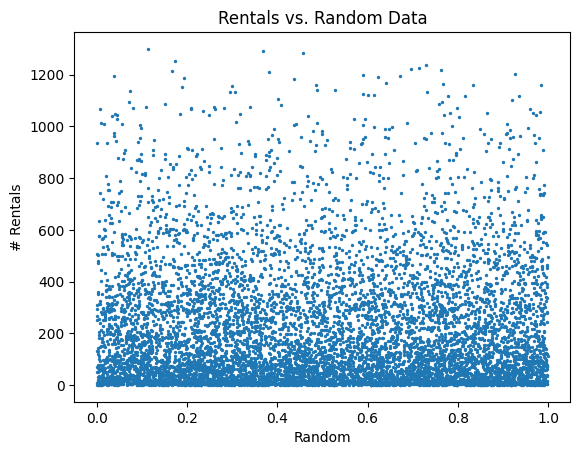

In [114]:
plt.scatter(df['random'],df['rentals'],s=2)
plt.title('Rentals vs. Random Data')
plt.xlabel('Random')
plt.ylabel('# Rentals')

In [115]:
est = ols(formula="rentals ~ temp + rel_humidity + random", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1161.
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       54.9580      9.849      5.580   

In [116]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.289
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     1168.
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57410.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        48.6214      9.242      5.261

In [117]:
est = ols(formula="rentals ~ temp + rel_humidity + windspeed", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     1161.
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57416.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8599   BIC:                         1.149e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       48.3642     11.325      4.271   

In [118]:
est = ols(formula="rentals ~ temp + rel_humidity + windspeed + precipitation", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.289
Method:                 Least Squares   F-statistic:                     876.1
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57409.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8598   BIC:                         1.149e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        40.8156     11.488      3.553

### Step 6: Check the importance of the variables
The variables only provide value when **(P>|t|) <= 0.005**. When the results are not in that range, the variable will produce more noise than help our model.
In that order of ideas, the previous step has show us that windspeed will not provide adecuate value because its (P>|t|) is higher as permited.
<br>
To add categorical values to the model and check its importance, I will use dummies. At least one of the dummies should be important for the complete set of dummy variables to be important. I will begin by splitting the data in train and test datasets and generating a first model. I will also check on the behaviour with each categorical variable as done before for windspeed and precipitation.

In [119]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + month", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     269.1
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57315.
No. Observations:                8603   AIC:                         1.147e+05
Df Residuals:                    8588   BIC:                         1.148e+05
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        56.1751     12.252      4.585

In [120]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + day", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.295
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     108.5
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57378.
No. Observations:                8603   AIC:                         1.148e+05
Df Residuals:                    8569   BIC:                         1.151e+05
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        51.3243     14.768      3.475

In [121]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + hour", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.642
Method:                 Least Squares   F-statistic:                     594.7
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -54446.
No. Observations:                8603   AIC:                         1.089e+05
Df Residuals:                    8576   BIC:                         1.091e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      -150.0144      9.821    -15.275

In [122]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + day_of_week", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     420.7
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57309.
No. Observations:                8603   AIC:                         1.146e+05
Df Residuals:                    8593   BIC:                         1.147e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             72.7698     10

In [123]:
est = ols(formula="rentals ~ temp + rel_humidity + precipitation + weekend", data=df).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     946.0
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -57311.
No. Observations:                8603   AIC:                         1.146e+05
Df Residuals:                    8598   BIC:                         1.147e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        74.2324      9.315      7.969

With the analysis done, I can conclude that the variable day will not be useful for the model because every one of their (P>|t|) are greater than 0.005. Another useful insight comes when seeing day of week and weekend, the dummies for the days of week that add value represent Saturdays and Sundays, which are weekends. Also, the R2 that came from weekend and day of the week is exactly the same. With both observations, I have concluded that it is a case of colinearity that could affect the robustness of the model. Then, to provide the best value possible, I will not use day_of_week and only use weekend in my final model.

### Step 7: Training the model
I will create a train and test data set with the columns remaining and then I will use the train dataset to develop my model.

In [124]:
df = df.drop(columns=['random'])
df_final = df.drop(columns=['temp_wb','windspeed','day','day_of_week'])

In [125]:
df_train, df_test = train_test_split(df_final, test_size=0.3, shuffle=True, random_state=42)

X = df_train.copy()
y = X.pop('rentals')
X_test = df_test.copy()
y_test = X_test.pop('rentals')


In [126]:
my_formula = 'rentals ~ ' + '+'.join(df_train.columns[1:])

est = ols(formula = my_formula, data=df_train).fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                rentals   R-squared:                       0.683
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     339.7
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:40:25   Log-Likelihood:                -37811.
No. Observations:                6022   AIC:                         7.570e+04
Df Residuals:                    5983   BIC:                         7.596e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -89.7447     13.190     -6.804

### Step 8: Testing the model

In [127]:
test_pred = est.predict(df_test)
print('OOS R-squared: '+str(r2_score(df_test['rentals'],test_pred)))

OOS R-squared: 0.679515733386181


### Step 9: Use the prediction to answer business questions
A probabilistic estimate will be well modeled as a Normal random variable that needs a mean and a standard deviation. To calculate the standard deviation of the residuals, I will use the square root of the average squared residuals. The mean will be obtained by calculating a point estimate when the conditions are defined.

In [128]:
# Standard deviation
print(np.sqrt(est.mse_resid))

129.4303985529663


To obtain the point estimate, I will predict the number of rentals when temp = 60F, rel_humidity = 50%, precipitation = 0.09, weekend = 1, hour = 15 and month = 6

In [129]:
print('y_pred = -89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1 = ' + str(-89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1))

y_pred = -89.7447 + 3.3416*60 - 1.3772*50 - 398.0061*0.09 - 61.6098*1 + 209.5526*1 + 121.4227*1 = 275.436251


Then the normal random variable for this prediction will have a mean of 275.44 and standard deviation 129.43. Now I could answer a question like 'What is the chance that the number of rentals exceeds 400 when the mentioned conditions are met?'. The answer will be the same as the probability that a Normal random variable with mean 275.44 and standard deviation 129.43 exceeds 400!

In [130]:
print('Probability of at least 400 rentals when the conditions are met: '+str(1-norm.cdf(400,loc=275.44,scale=129.43)))

Probability of at least 400 rentals when the conditions are met: 0.16793101421656675


Now that I have build a linear regression model, I will train a regression tree to see how well it behaves with the same initial dataset. The regression tree will split the dataset in subsets based on feature values.

### Step 10: Split the original dataset into train and test
The split will be the same as the used for the linear regression model (70/30). To help with the evaluation, I will create a function for the calculation of OSR2 for regression trees. Finally, to see it in graphic, I will create function to check the tree.

In [131]:
df_train, df_test = train_test_split(df, test_size=0.3, shuffle=True, random_state=42)

X = df_train.copy()
y = X.pop('rentals')
X_test = df_test.copy()
y_test = X_test.pop('rentals')

In [132]:
def OSR2(y_pred, y_true, training_mean):
  '''
  Calculates out-of-sample R-squared
  '''
  baseline_error = np.sum(np.square((training_mean - y_true)))
  model_error = np.sum(np.square((y_pred - y_true)))
  return 1.0 - model_error/baseline_error

In [133]:
def viz_tree(tree, font=12, figsize=(16,10)):
  '''
  draws a classification tree
  '''
  plt.figure(figsize=figsize)  # set plot size (denoted in inches)
  _ = plot_tree(tree,
                feature_names=X.columns,
                filled=True,
                fontsize=font)

### Step 11: Building a Tree with Default Parameters
First I will define the random_state for the model. Then, I will one-hot encode the categorical variables before feeding it to the Regression Tree. This is an extra step that need to be taken compared to the ones done for linear regression for the model to be built without issues.

In [134]:
tree = DecisionTreeRegressor(random_state=42)

In [135]:
X = pd.get_dummies(X, columns = categorical_variables)
X_test = pd.get_dummies(X_test, columns = categorical_variables)

In [136]:
X.head()

,temp,temp_wb,rel_humidity,windspeed,precipitation,month_1,month_2,month_3,month_4,month_5,...,hour_23,day_of_week_Fri,day_of_week_Mon,day_of_week_Sat,day_of_week_Sun,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed,weekend_0,weekend_1
5156,84,74,61,10,0.00,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
6290,70,68,90,5,0.00,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2646,57,49,53,13,0.00,False,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
439,46,39,51,5,0.00,True,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1379,41,39,86,46,0.03,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False


Now I will build the regression tree with the default settings.

In [137]:
tree.fit(X,y)

DecisionTreeRegressor(random_state=42)

### Step 12: Check OSR2 on train and test

In [138]:
print('The OSR2 for the train data set is: '+str(OSR2(tree.predict(X), y, y.mean())))

The OSR2 for the train data set is: 1.0


In [139]:
print('The OSR2 for the test data set is: '+str(OSR2(tree.predict(X_test), y_test, y.mean())))

The OSR2 for the test data set is: 0.7824430330733544


Having an OSR2 of 100% in the training set and an OSR2 of 78% is a clear sign of overfitting. Then, I will prune the tree to provide the model with more robustness and avoid overfitting. First, I will check how big the tree is.

In [140]:
tree.tree_.node_count, tree.tree_.max_depth

(11301, 47)

I will cost complexity pruning to control overfitting by using a parameter called ccp_alpha that penalizes tree complexity. The steps are the following:
- Generating a sequence of pruned trees for different ccp_alpha values.
- Evaluating each tree's performance on out-of-sample data.
- Selecting the tree that offers the best trade-off between complexity and predictive performance.

This approach ensures the final tree is smaller, interpretable, and generalizes better.

### Step 13: Generate pruned trees

In [141]:
tree = DecisionTreeRegressor(random_state=42)

In [142]:
path = tree.cost_complexity_pruning_path(X,y)

In [143]:
alphas = path.ccp_alphas

In [144]:
len(alphas)

5186

Because there are too many of them, I will generate about ~50 trees, evenly sampled from this group.

In [145]:
alphas_small = alphas[::100]
alphas_small = alphas_small[::-1]

In [146]:
r2_all = []
osr2_all = []
node_counts = []

for alpha in alphas_small:
  tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
  tree.fit(X,y)
  y_pred = tree.predict(X)
  r2_all.append(OSR2(y_pred, y, y.mean()))
  y_pred = tree.predict(X_test)
  osr2_all.append(OSR2(y_pred, y_test, y.mean()))
  node_counts.append(tree.tree_.node_count)

### Step 14: Evaluate performance of each using OSR2



Text(0.5, 1.0, 'Prediction quality vs tree size')

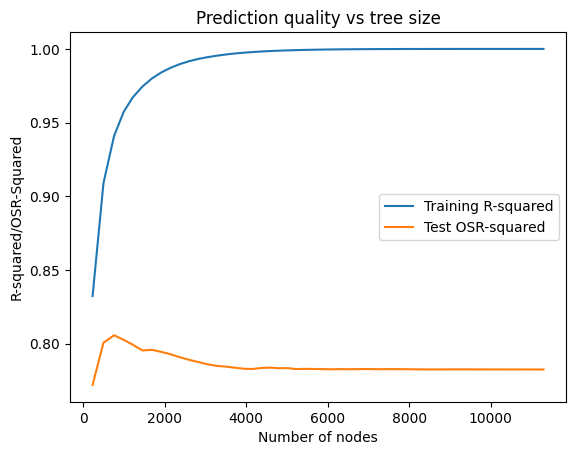

In [147]:
plt.plot(node_counts, r2_all, label='Training R-squared')
plt.plot(node_counts, osr2_all, label='Test OSR-squared')
plt.legend()
plt.xlabel('Number of nodes')
plt.ylabel('R-squared/OSR-Squared')
plt.title('Prediction quality vs tree size')

I can conclude that as the tree size (i.e., number of nodes) increases, the training set R2 gets better but the test set OSR2 peaks around 0.8 and then decreases as overfitting kicks in.

### Step 15: Use the best pruned tree
I will obtain the ccp_alpha to use by searching the best osr2 of the list. Then, I will use the parameter to build the tree

In [148]:
opt_idx = np.argmax(osr2_all)

In [149]:
alphas_small[opt_idx]

np.float64(9.300806457131927)

In [150]:
tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alphas_small[opt_idx])
tree.fit(X,y)

DecisionTreeRegressor(ccp_alpha=np.float64(9.300806457131927), random_state=42)

In [151]:
tree.tree_.node_count, tree.tree_.max_depth

(753, 30)

It is still big, but not huge anymore. It represents better the data. I will use a command to visualize the tree.

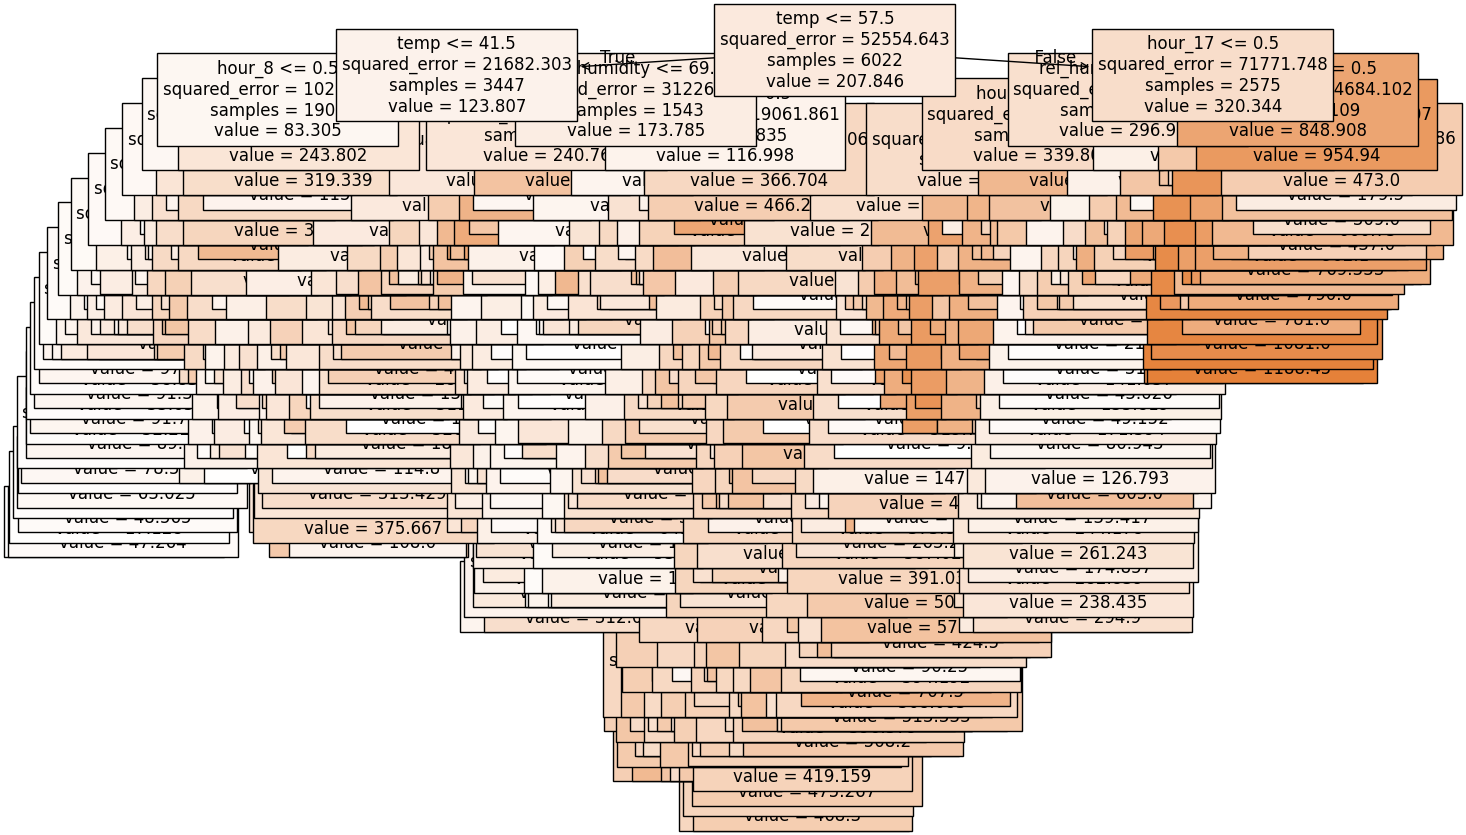

In [152]:
viz_tree(tree)

### Step 15: Confirm the OSR2 estimated
This tree's OSR2 should be around 0.8

In [153]:
OSR2(tree.predict(X_test), y_test, y.mean())

np.float64(0.8056467590667243)

### Overall Summary
- Linear regression: OSR² ≈ 0.68.
- Unpruned CART: OSR² ≈ 0.78 (overfitting, huge tree).
- Pruned CART: OSR² ≈ 0.81 with a moderate tree size.
<br>For this data set, the pruned regression tree obtains the best performance, great interpretability and is good in generalizing unseen data.